In [134]:

import math
import matplotlib.pyplot as plt
import numpy as np

import rainbow.math.involute as INVOLUTE

from rainbow.procedural.gears.types import SpurGearSpec

plt.rc('font', size=12)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

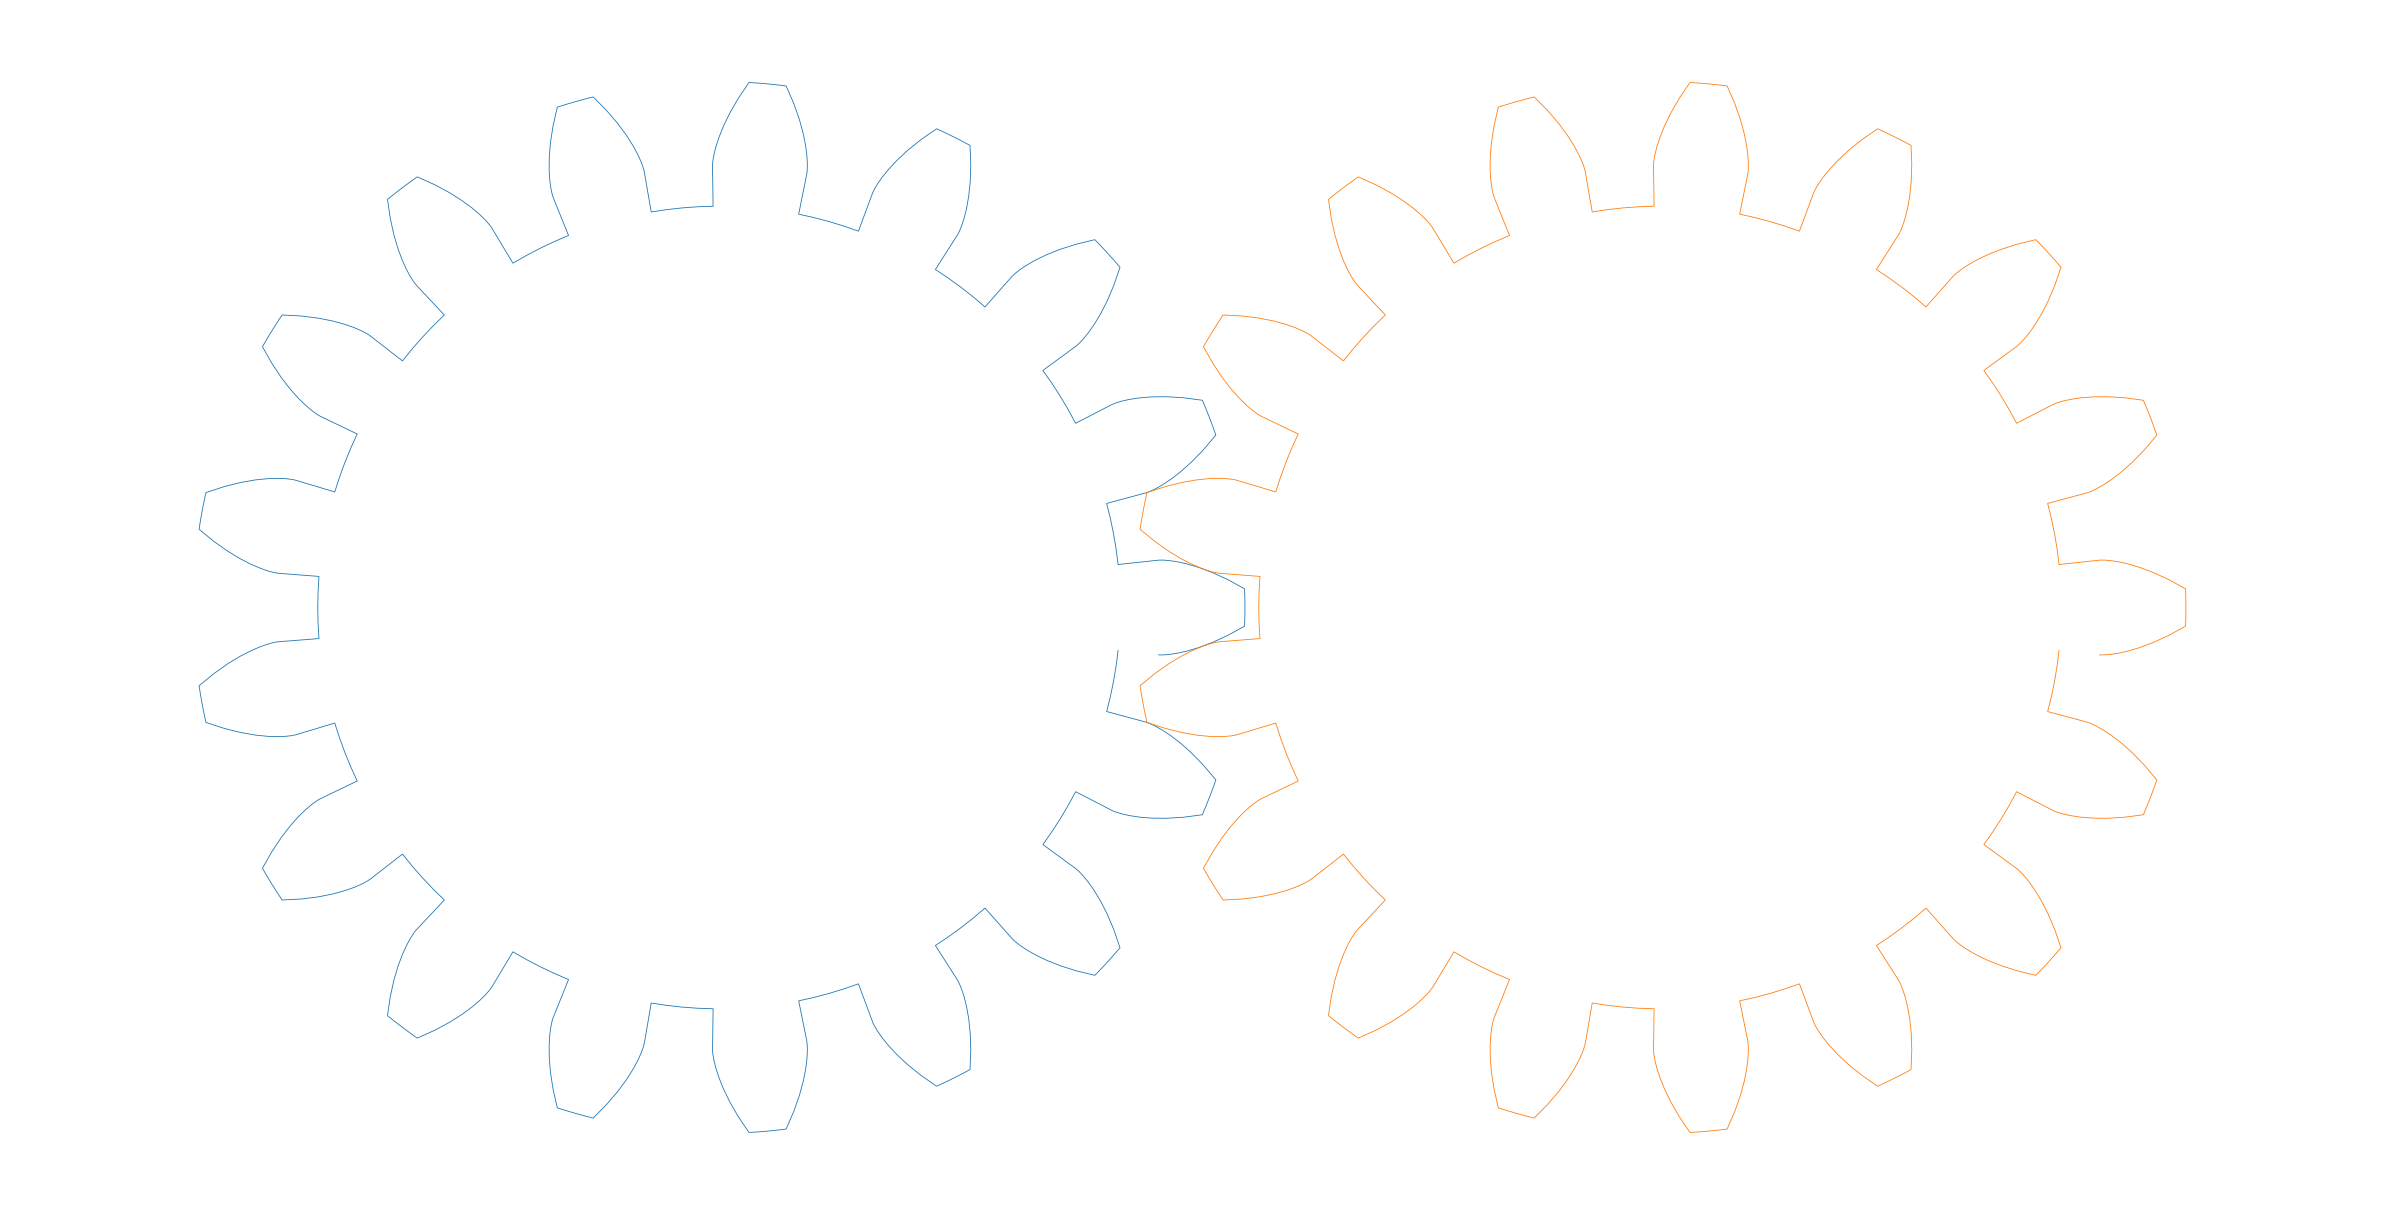

In [135]:
spec = SpurGearSpec(1, 17, is_internal=True)

plt.figure(figsize=(10, 5), dpi=300)
plt.grid(True)
plt.axis('equal')
plt.axis('off')

side_points = 10
top_points = 3
bottom_points = 3

ts = np.linspace(spec.t_min, spec.t_max, side_points)
rev_ts = -ts[::-1]

xs = []
ys = []
for idx in range(spec.z):
    theta_i = spec.theta_i[idx]
    theta_i_next = spec.theta_i[(idx + 1) % spec.z]
    if theta_i_next < theta_i:
        theta_i_next += 2 * math.pi
    
    right_root_offset = theta_i - spec.gamma_b / 2
    left_root_offset = theta_i + spec.gamma_b / 2
    
    # Right side
    right_inv_x = INVOLUTE.create_involute_x_function(spec.rb, right_root_offset)
    right_inv_y = INVOLUTE.create_involute_y_function(spec.rb, right_root_offset)
    xs.extend(right_inv_x(ts))
    ys.extend(right_inv_y(ts))
    
    # Top
    right_top_offset = theta_i - spec.gamma_a / 2
    left_top_offset = theta_i + spec.gamma_a / 2
    top_theta = np.linspace(right_top_offset, left_top_offset, top_points + 2)[1:-1]
    xs.extend(spec.ra * np.cos(top_theta))
    ys.extend(spec.ra * np.sin(top_theta))
    
    # Left side
    left_inv_x = INVOLUTE.create_involute_x_function(spec.rb, left_root_offset)
    left_inv_y = INVOLUTE.create_involute_y_function(spec.rb, left_root_offset)
    xs.extend(left_inv_x(rev_ts))
    ys.extend(left_inv_y(rev_ts))
    
    # Bottom
    if spec.rb >= spec.rd:
        bottom_theta = np.linspace(left_root_offset, left_root_offset + 2 * spec.gamma_p - spec.gamma_b, bottom_points + 2)
        xs.extend(spec.rd * np.cos(bottom_theta))
        ys.extend(spec.rd * np.sin(bottom_theta))
    else:
        bottom_start = theta_i + spec.gamma_d / 2
        bottom_end = theta_i_next - spec.gamma_d / 2
        bottom_theta = np.linspace(bottom_start, bottom_end, bottom_points + 2)[1:-1]
        xs.extend(spec.rd * np.cos(bottom_theta))
        ys.extend(spec.rd * np.sin(bottom_theta))

plt.plot(xs, ys, linewidth=0.2)
plt.plot([x + 2 * spec.rp for x in xs], ys, linewidth=0.2)

In [136]:
points_per_tooth = 2 * side_points + top_points + ((bottom_points + 2) if spec.rb >= spec.rd else bottom_points)
total_points = spec.z * points_per_tooth

print(f'Total points: {total_points}')
print(len(xs))
print(len(ys))

inner_r = (0.5 + int(spec.is_internal)) * spec.rp
inner_theta = np.linspace(0, 2 * math.pi, spec.z + 1)[:-1]
if spec.is_internal:
    inner_theta += math.pi / spec.z

inner_xs = inner_r * np.cos(inner_theta)
inner_ys = inner_r * np.sin(inner_theta)
xs.extend(inner_xs)
ys.extend(inner_ys)

Total points: 476
476
476


Index shift: 12


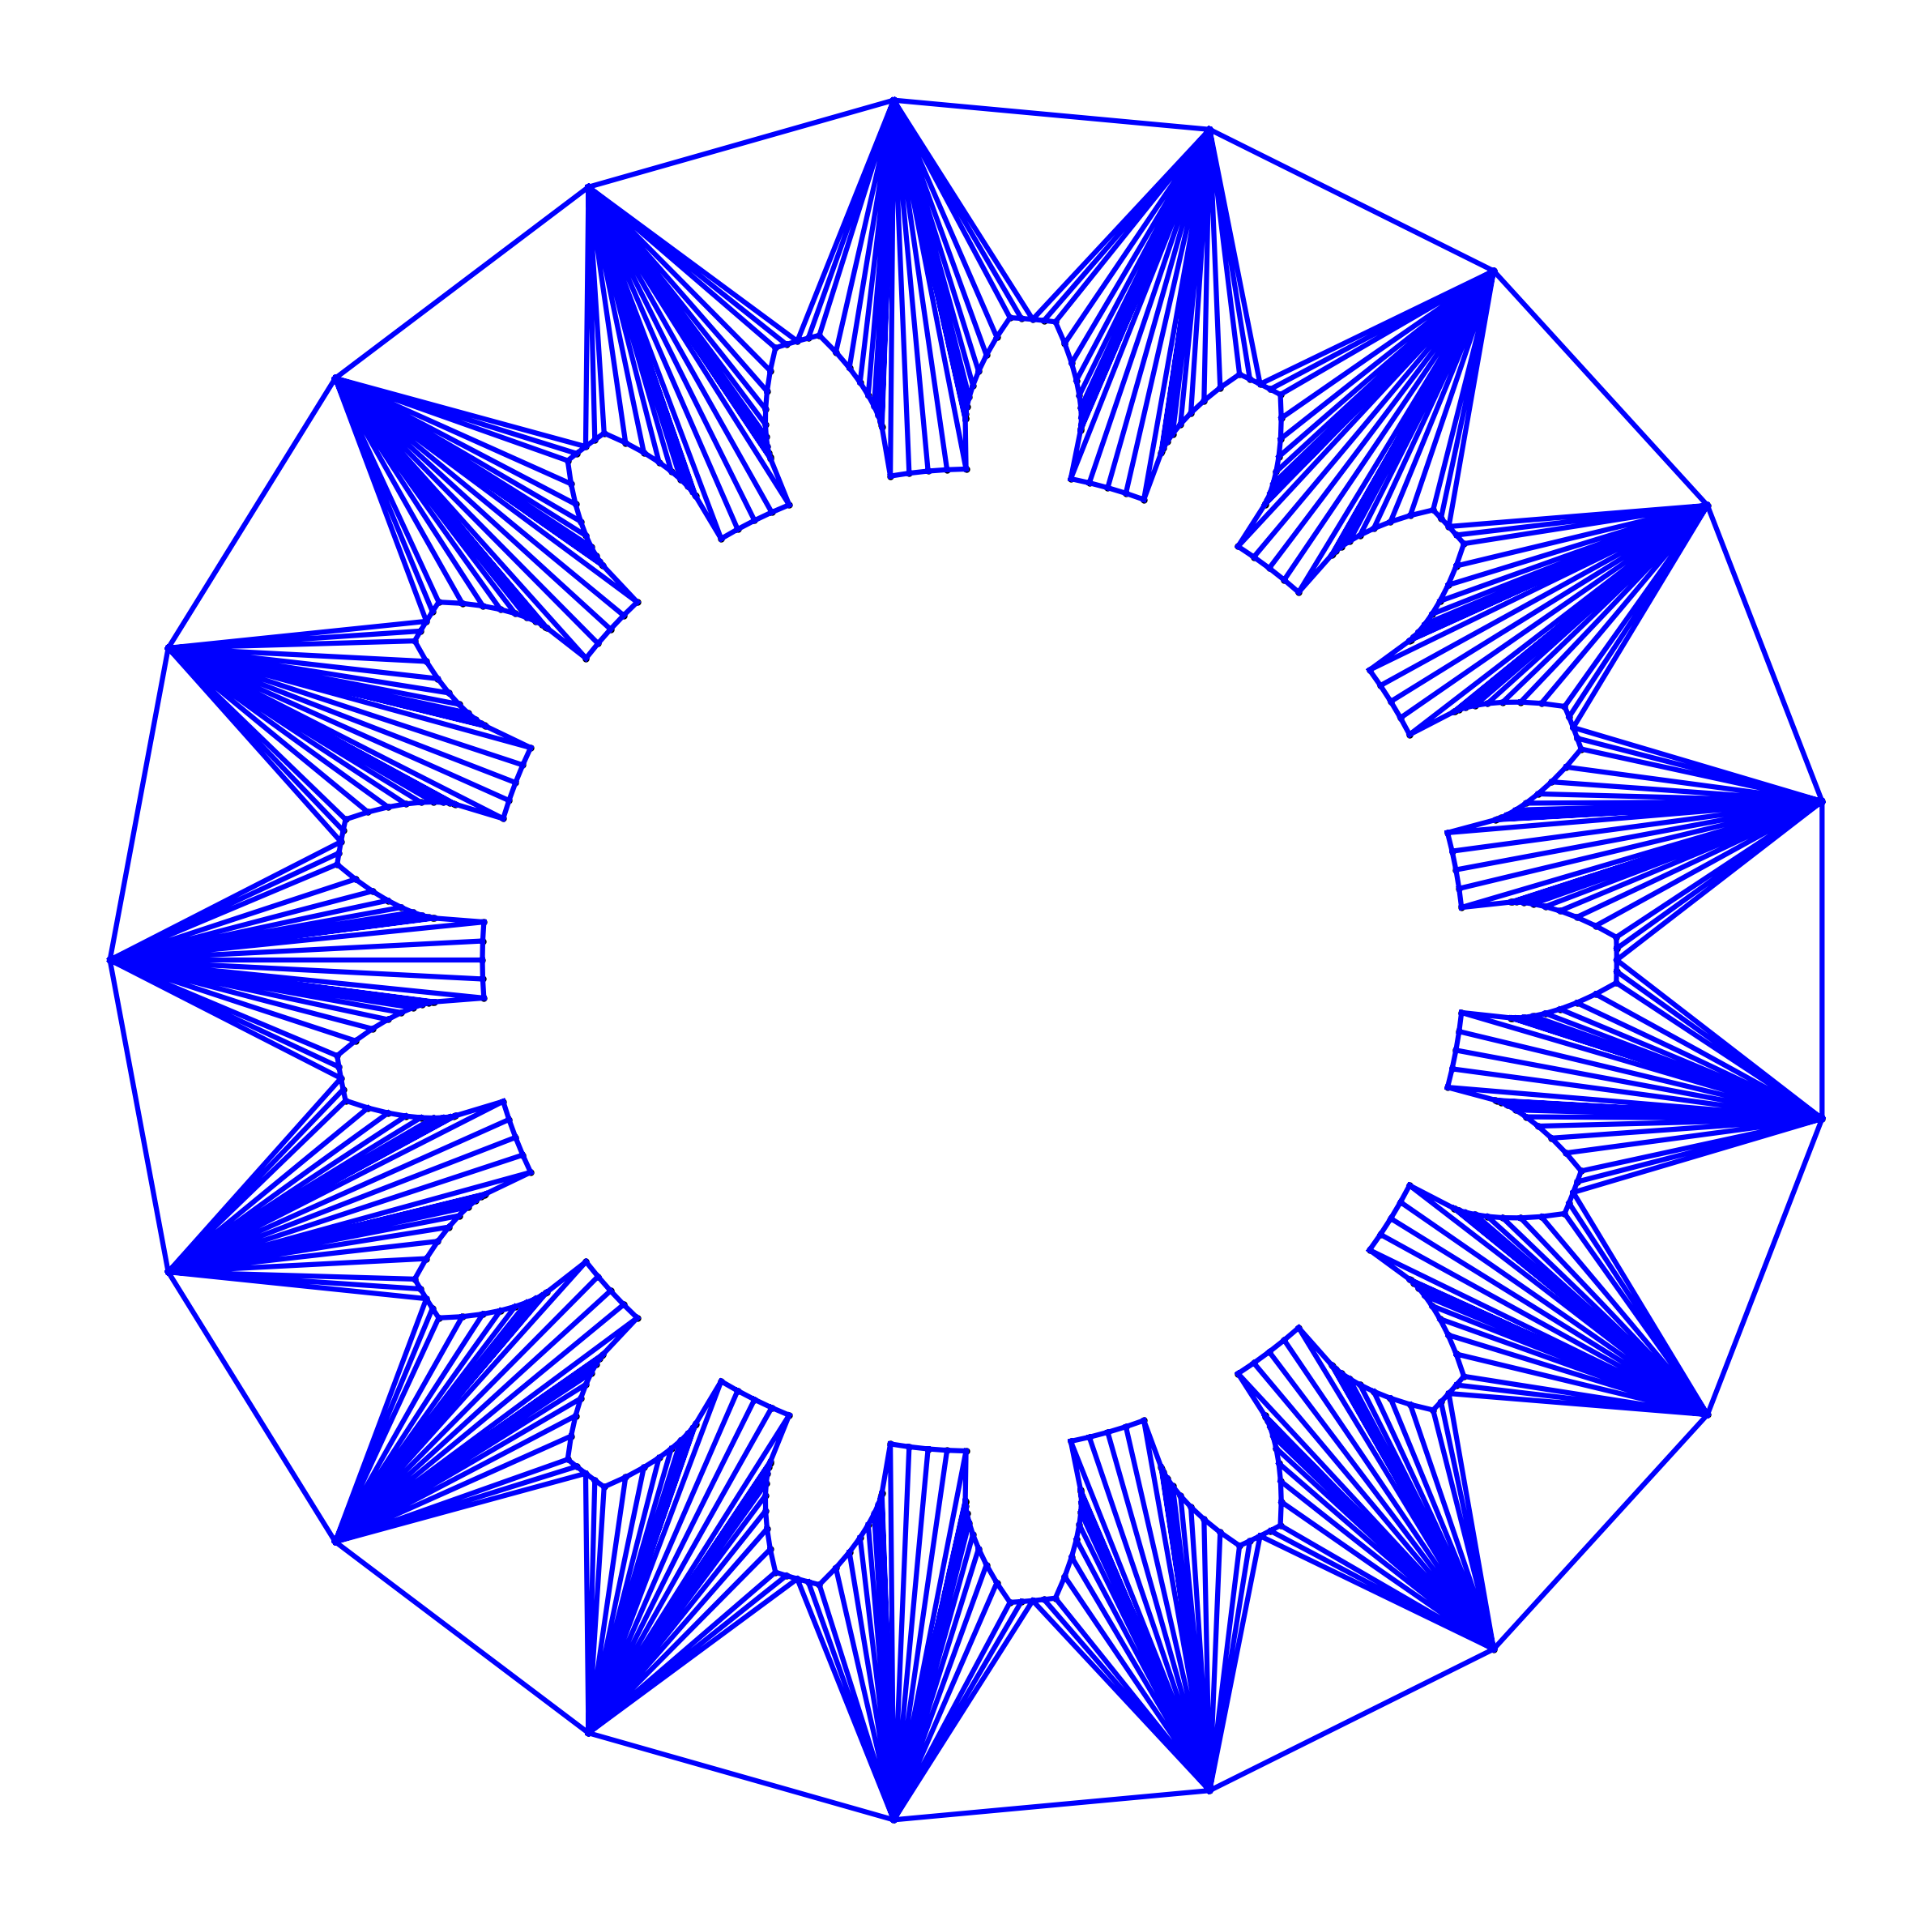

In [137]:
V = np.vstack((xs, ys)).T
T = []

if not spec.is_internal:
    for idx in range(total_points):
        i = idx - 1
        if i < 0:
            i = total_points - 1
        j = idx
        k = idx // points_per_tooth + total_points
        T.append((i, j, k))
        
        next_k = (idx + 1) // points_per_tooth + total_points
        if next_k == total_points + spec.z:
            next_k = total_points

        if next_k != k:
            T.append((j, next_k, k))
else:
    index_shift = (points_per_tooth - top_points) // 2
    print(f'Index shift: {index_shift}')
    profile_indices = np.array([[i + j * points_per_tooth for i in range(points_per_tooth)] for j in range(spec.z)])
    profile_indices = (profile_indices + index_shift) % total_points
    circle_indices = np.array(range(total_points, total_points + spec.z))
    
    for k, (ci, pi) in enumerate(zip(circle_indices, profile_indices)):
        T.append((ci, pi[0], profile_indices[k-1][-1]))
        T.append((ci, profile_indices[k-1][-1], circle_indices[k-1]))
        for i in range(points_per_tooth - 1):
            j = (i + 1) % points_per_tooth
            T.append((pi[i], pi[j], ci))
            T.append((pi[j], ci, pi[i]))
    
    

plt.figure(figsize=(10, 10), dpi=300)
plt.grid(True)
plt.axis('equal')
plt.axis('off')

plt.scatter(V[:, 0], V[:, 1], s=1, c='black')
plt.triplot(V[:, 0], V[:, 1], T, color='blue')